# Assignment 2: Sentiment Analysis

Reetika Singh

In [1]:
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
dfMovieReview = 'MovieReview-Sample.csv'
movieData = pd.read_csv(dfMovieReview, header=None, names=['text', 'label'])

# Converting to string
movieData['text'] = movieData['text'].astype(str)

print(f"Total reviews loaded: {len(movieData)}")
movieData.head()

Total reviews loaded: 2000


,text,label
1,films adapted from comic books have had plenty...,1
2,every now and then a movie comes along from a ...,1
3,you've got mail works alot better than it dese...,1
4,jaws is a rare film that grabs your attent...,1
5,moviemaking is a lot like being the general ma...,1


In [4]:
# Load LM Dictionary
def load_word_list(file_path):
    with open(file_path, 'r') as f:
        words = f.read().splitlines()
        words = [w.strip() for w in words if w.strip() and not w.startswith(';')]
    return set(words)

lmPositiveWords = load_word_list('positive-words-LM.txt')
lmNegativeWords = load_word_list('negative-words-LM.txt')

# Lower + Upper versions
lmPositiveLower = set(w.lower() for w in lmPositiveWords)
lmNegativeLower = set(w.lower() for w in lmNegativeWords)

lmPositiveUpper = set(w.upper() for w in lmPositiveWords)
lmNegativeUpper = set(w.upper() for w in lmNegativeWords)

In [5]:
# Tokenization
stop_words = set(stopwords.words('english'))

def tokenize(text):
    tokens = word_tokenize(text)
    words = [w.lower() for w in tokens if w.isalpha() and w.lower() not in stop_words]
    return words

In [8]:
# Sentiment Fuctions

# 1. Bing Liu
def getBingSentiment(reviewText):
    tokens = tokenize(str(reviewText))
    posCount = sum(1 for word in tokens if word in lmPositiveLower)
    negCount = sum(1 for word in tokens if word in lmNegativeLower)
    return 1 if posCount >= negCount else 0

# 2. LM Dictionary
def getLmSentiment(reviewText):
    tokens = [w.upper() for w in tokenize(str(reviewText))]
    posCount = sum(1 for word in tokens if word in lmPositiveUpper)
    negCount = sum(1 for word in tokens if word in lmNegativeUpper)
    return 1 if posCount >= negCount else 0

# 3. TextBlob
def getTextBlobSentiment(reviewText):
    analysis = TextBlob(str(reviewText))
    return 1 if analysis.sentiment.polarity >= 0 else 0

# 4. Vader
vaderAnalyzer = SentimentIntensityAnalyzer()

def getVaderSentiment(reviewText):
    score = vaderAnalyzer.polarity_scores(str(reviewText))['compound']
    return 1 if score >= 0 else 0

In [9]:
# Apply
movieData['predBing'] = movieData['text'].apply(getBingSentiment)
movieData['predLM'] = movieData['text'].apply(getLmSentiment)
movieData['predTextBlob'] = movieData['text'].apply(getTextBlobSentiment)
movieData['predVader'] = movieData['text'].apply(getVaderSentiment)

In [10]:
# Metrics Fuction
def calculateFullMetrics(goldStandard, predictions):
    p, r, f, _ = precision_recall_fscore_support(
        goldStandard, predictions, labels=[0, 1], zero_division=0
    )

    return {
        'Neg Precision': p[0],
        'Pos Precision': p[1],
        'Avg Precision': np.mean(p),
        'Neg Recall': r[0],
        'Pos Recall': r[1],
        'Avg Recall': np.mean(r),
        'Neg F-measure': f[0],
        'Pos F-measure': f[1],
        'Avg F-measure': np.mean(f)
    }

## 1. Performance Comparison Table

In [11]:
resultsList = []

modelNames = [
    ('Bing Liu', 'predBing'),
    ('LM Dictionary', 'predLM'),
    ('TextBlob', 'predTextBlob'),
    ('Vader', 'predVader')
]

for displayName, colName in modelNames:
    metrics = calculateFullMetrics(movieData['label'], movieData[colName])
    metrics['Model'] = displayName
    resultsList.append(metrics)

comparisonTable = pd.DataFrame(resultsList).set_index('Model')

display(comparisonTable.style.highlight_max(axis=0, color='lightgreen', subset=['Avg F-measure']))

,Neg Precision,Pos Precision,Avg Precision,Neg Recall,Pos Recall,Avg Recall,Neg F-measure,Pos F-measure,Avg F-measure
Model,,,,,,,,,
Bing Liu,0.567083,0.619777,0.593430,0.727000,0.445000,0.586000,0.637160,0.518044,0.577602
LM Dictionary,0.567083,0.619777,0.593430,0.727000,0.445000,0.586000,0.637160,0.518044,0.577602
TextBlob,0.776204,0.559199,0.667701,0.274000,0.921000,0.597500,0.405026,0.695882,0.550454
Vader,0.630907,0.584224,0.607565,0.494000,0.711000,0.602500,0.554122,0.641407,0.597765


## 2. Ensemble

In [12]:
def evaluate_prediction(label_col, pred_col):
    unique_labels = sorted(label_col.unique())
    results = {}

    for label in unique_labels:
        y_true = label_col == label
        y_pred = pred_col == label

        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        results[label] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f-measure': f1
        }

    return pd.DataFrame.from_dict(results, orient='index')

# Select top 3 models
topThreeModels = comparisonTable.sort_values(by='Avg F-measure', ascending=False).head(3).index.tolist()

columnMapping = {
    'Bing Liu': 'predBing',
    'LM Dictionary': 'predLM',
    'TextBlob': 'predTextBlob',
    'Vader': 'predVader'
}

ensembleColumns = [columnMapping[m] for m in topThreeModels]

# Majority vote
def majority_vote(pred_cols, tie_label=1):
    modes_df = pred_cols.mode(axis=1)
    modes_df = modes_df.apply(lambda x: x.dropna().tolist(), axis=1)
    modes_df = modes_df.apply(lambda x: int(x[0] if len(x) == 1 else tie_label))
    return modes_df

movieData['predEnsemble'] = majority_vote(movieData[ensembleColumns], tie_label=1)

In [13]:
ensembleMetrics = evaluate_prediction(movieData['label'], movieData['predEnsemble'])

ensembleF1 = ensembleMetrics['f-measure'].mean()
bestSingleF1 = comparisonTable['Avg F-measure'].max()

percentageImprovement = ((ensembleF1 - bestSingleF1) / bestSingleF1) * 100

print(f"Ensemble Avg F-measure: {ensembleF1:.4f}")
print(f"Improvement over best single model: {percentageImprovement:.2f}%")

Ensemble Avg F-measure: 0.5776
Improvement over best single model: -3.37%


## 3. Feature-Based Sentiment

In [14]:
# Keywords
featureKeywords = {
    'acting': ['acting', 'performance', 'cast', 'actors', 'actresses', 'portrayal'],
    'plot': ['plot', 'story', 'narrative', 'script', 'screenplay', 'storyline'],
    'visuals': ['visuals', 'cinematography', 'effects', 'scenery', 'graphics', 'visual'],
    'director': ['director', 'filmmaker', 'direction', 'directing']
}

def getFeatureSentiment(reviewText, featureKeywords):
    featureResults = {}
    sentences = nltk.sent_tokenize(str(reviewText).lower())

    for feature, keywords in featureKeywords.items():
        relevantSentences = [s for s in sentences if any(k in s for k in keywords)]

        if not relevantSentences:
            featureResults[feature] = None
        else:
            scores = [vaderAnalyzer.polarity_scores(s)['compound'] for s in relevantSentences]
            avgScore = sum(scores) / len(scores)
            featureResults[feature] = 1 if avgScore >= 0 else 0

    return featureResults

# Apply to dataset
featureData = movieData['text'].apply(lambda x: getFeatureSentiment(x, featureKeywords))
featureDf = pd.DataFrame(featureData.tolist())

# Merge with original data
finalFeatureAnalysisDf = pd.concat([movieData[['text', 'label']], featureDf], axis=1)

print("Feature-Based Sentiment")
display(finalFeatureAnalysisDf.head(5))

Feature-Based Sentiment


,text,label,acting,plot,visuals,director
1,films adapted from comic books have had plenty...,1.0,NaN,0.0,NaN,NaN
2,every now and then a movie comes along from a ...,1.0,0.0,1.0,NaN,1.0
3,you've got mail works alot better than it dese...,1.0,NaN,NaN,NaN,1.0
4,jaws is a rare film that grabs your attent...,1.0,1.0,1.0,1.0,1.0
5,moviemaking is a lot like being the general ma...,1.0,NaN,1.0,NaN,1.0


Visualization

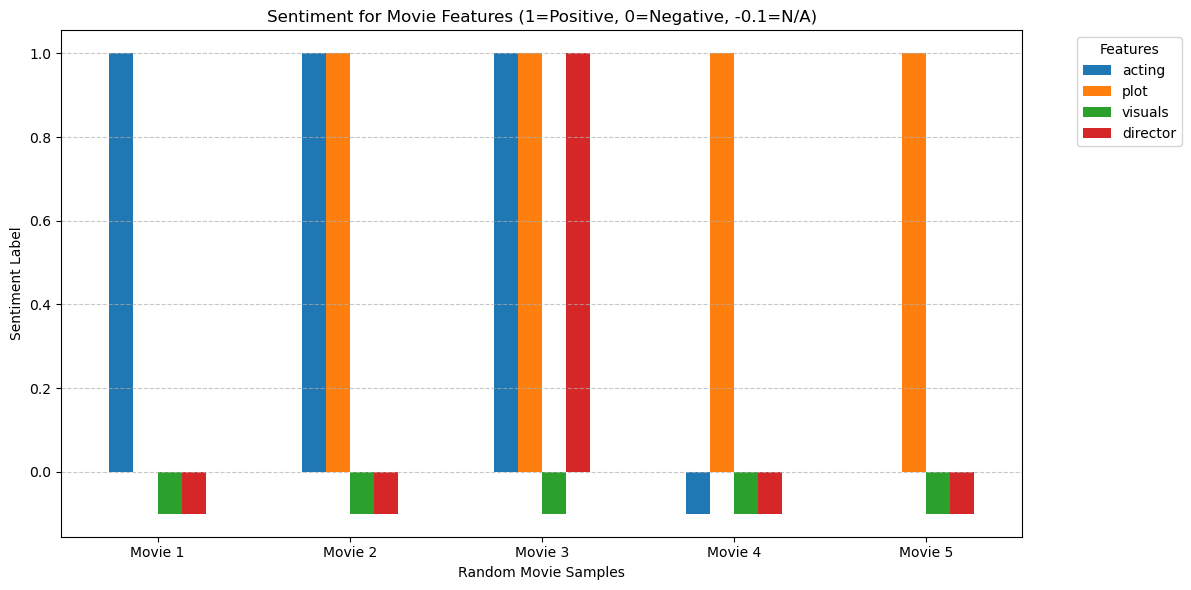

In [15]:
# Randomly selecting 5 movies
randomMovies = finalFeatureAnalysisDf.sample(5, random_state=78).copy()
randomMovies.index = [f"Movie {i+1}" for i in range(5)]

plotDataBar = randomMovies[list(featureKeywords.keys())].fillna(-0.1)

# Bar plot
plotDataBar.plot(kind='bar', figsize=(12, 6))

plt.title("Sentiment for Movie Features (1=Positive, 0=Negative, -0.1=N/A)")
plt.ylabel("Sentiment Label")
plt.xlabel("Random Movie Samples")
plt.xticks(rotation=0)
plt.legend(title="Features", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### The chart shows that while people talk about acting in almost every selected review and usually love it, they rarely mention things like visuals or the director. 

#### This explains why there are so many empty gaps (N/A) in the data, which is expected in unstructured text data. 

#### It is also interesting to see that reviewers can be picky; for example, in Movie 2, the user really liked the acting but thought the plot was actually quite bad.